Epoch [10/50] Loss: 0.000135
Epoch [20/50] Loss: 0.000156
Epoch [30/50] Loss: 0.000122
Epoch [40/50] Loss: 0.000171
Epoch [50/50] Loss: 0.000201
--- TRAIN SET Metrics (raw) ---
MAE : 1.1218
RMSE: 1.5475
R^2 : 0.9959



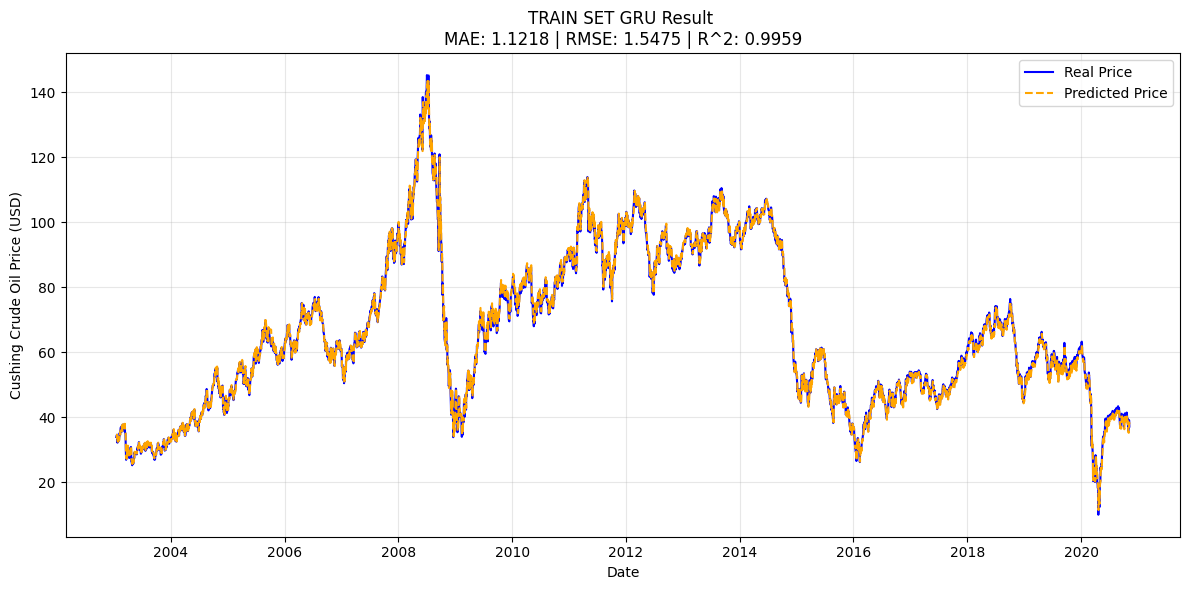

--- TEST SET Metrics (raw) ---
MAE : 1.7859
RMSE: 2.3603
R^2 : 0.9704



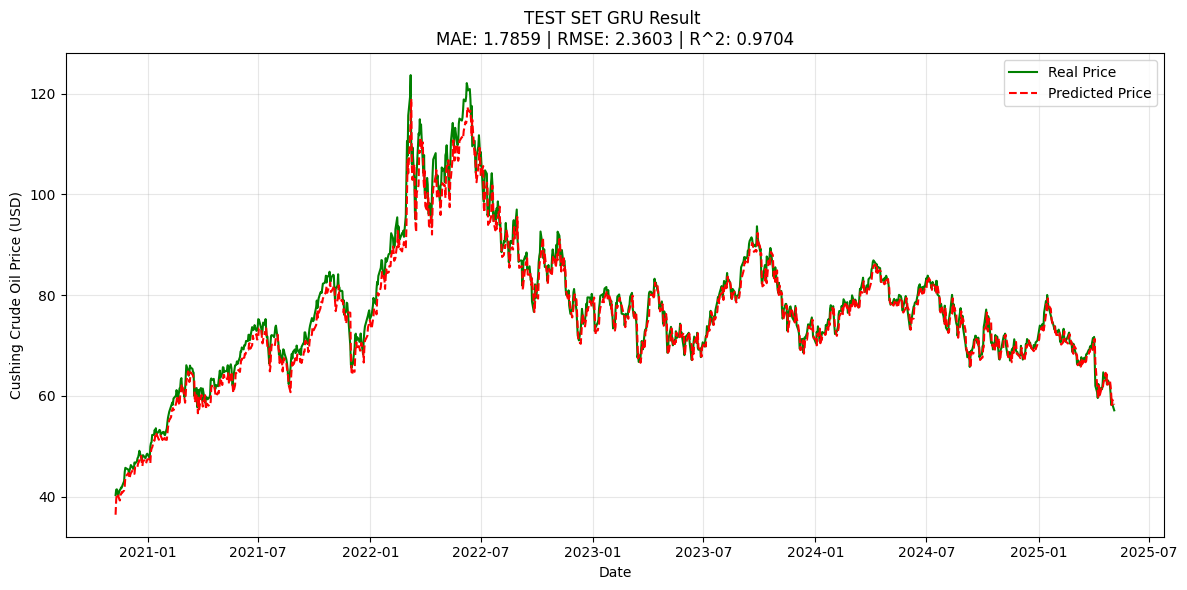

In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Data Preparation (Modified to fit Scaler only on Train set)
df = pd.read_csv('compiled_dataset.csv', parse_dates=['Date'])
data = df.sort_values('Date').reset_index(drop=True)

features = [
    'dow_jones_adj_close_price', 'nasdaq_adj_close_price', 'sp_adj_close_price',
    'usd_to_uk_exchange_rate', 'treasury_1_year_rate',
    'breakeven_inflation_5_year_rate', 'bank_prime_loan_rate', 'federal_funds_rate',
    'cushing_crude_oil_price'
]
target = 'cushing_crude_oil_price'

# Xác định điểm cắt 80% trên dữ liệu gốc
split_idx = int(len(data) * 0.8)

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# fit (học min/max) trên 80% dữ liệu đầu (Train)
feature_scaler.fit(data[features].values[:split_idx])
target_scaler.fit(data[[target]].values[:split_idx])

# Sau đó transform (áp dụng) cho TOÀN BỘ dữ liệu
scaled_features = feature_scaler.transform(data[features].values)
scaled_target = target_scaler.transform(data[[target]].values)
dates = data['Date'].values

def create_sequences(features_arr, target_arr, lookback=1):
    X, y = [], []
    for i in range(lookback, len(features_arr)):
        X.append(features_arr[i - lookback:i])
        y.append(target_arr[i])
    return np.array(X), np.array(y)

lookback = 1
X, y = create_sequences(scaled_features, scaled_target, lookback)
sample_dates = dates[lookback:]

# Chia sequence theo tỷ lệ 80/20 tương ứng
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]
dates_train, dates_test = sample_dates[:train_size], sample_dates[train_size:]

# 2. Convert to Tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=128, shuffle=False)

# 3. Model Definition
class GRURegressor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2):
        super(GRURegressor, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model = GRURegressor(input_size=X_train.shape[-1]).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.007586)

# 4. Training Loop
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * bx.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.6f}")

# Save Checkpoint
torch.save({
    "model_state_dict": model.state_dict(),
    "feature_scaler": feature_scaler, # Lưu scaler đã fit trên train
    "target_scaler": target_scaler,
    "config": {"lookback": lookback, "input_size": X_train.shape[-1]}
}, "gru_oil_price_checkpoint.pth")

# 5. Evaluation & Visualization
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(X_train_t).cpu().numpy()
    y_test_pred_scaled = model(X_test_t).cpu().numpy()

def evaluate_and_plot(y_true_scaled, y_pred_scaled, dates, label, color_true, color_pred):
    y_true = target_scaler.inverse_transform(y_true_scaled)
    y_pred = target_scaler.inverse_transform(y_pred_scaled)
    
    y_true_exp = np.exp(y_true)
    y_pred_exp = np.exp(y_pred)
    
    mae = mean_absolute_error(y_true_exp, y_pred_exp)
    rmse = np.sqrt(mean_squared_error(y_true_exp, y_pred_exp))
    r2 = r2_score(y_true_exp, y_pred_exp)
    
    print(f"--- {label} Metrics (raw) ---")
    print(f"MAE : {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R^2 : {r2:.4f}\n")
    
    plt.figure(figsize=(12, 6))
    plt.plot(dates, y_true_exp.flatten(), label="Real Price", color=color_true)
    plt.plot(dates, y_pred_exp.flatten(), label="Predicted Price", color=color_pred, linestyle='--')
    plt.ylabel("Cushing Crude Oil Price (USD)")
    plt.xlabel("Date")
    plt.title(f"{label} GRU Result \nMAE: {mae:.4f} | RMSE: {rmse:.4f} | R^2: {r2:.4f}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

evaluate_and_plot(y_train, y_train_pred_scaled, dates_train, "TRAIN SET", 'blue', 'orange')
evaluate_and_plot(y_test, y_test_pred_scaled, dates_test, "TEST SET", 'green', 'red')